<a href="https://colab.research.google.com/github/YongmeiWang272/Microbiome-Niche-Prediction/blob/main/Random_Forest_Microbiome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 导入数据分析神器 pandas，并给它起个简写叫 pd
import pandas as pd

# 1. 读取你刚刚上传的 CSV 文件
df = pd.read_csv('project_catalog.csv')

# 2. 看看这个表有多大（多少行，多少列）
print(f"这个数据集共有 {df.shape[0]} 行，{df.shape[1]} 列。")
print("-" * 30)

# 3. 偷瞄一眼数据的前 5 行，确认是不是跟 Kaggle 截图里长得一样
display(df.head())

# 4. 统计一下：这个库里的细菌，各大身体部位（肠道、口腔、皮肤等）分别占了多少种？
print("\n=== 各身体部位分离出的细菌种类统计 ===")
# 注意：列名必须和截图里一模一样
print(df['HMP Isolation Body Site'].value_counts())

这个数据集共有 2915 行，17 列。
------------------------------


,HMP ID,GOLD ID,Organism Name,Domain,NCBI Superkingdom,HMP Isolation Body Site,Project Status,Current Finishing Level,NCBI Submission Status,NCBI Project ID,Genbank ID,Gene Count,IMG/HMP ID,HOMD ID,Sequencing Center,Funding Source,Strain Repository ID
0,1,Gi03551,Abiotrophia defectiva ATCC 49176,BACTERIAL,Bacteria,oral,Complete,Level 3: Improved-High-Quality Draft,6. annotation (and sequence) public on NCBI site,33011,ACIN00000000,1950,643886181,HOMD: tax_389,Washington University Genome Sequencing Center,NIH-HMP Jumpstart Supplement,"ATCC 49176, CIP 103242"
1,4,Gi03555,Achromobacter piechaudii ATCC 43553,BACTERIAL,Bacteria,airways,Complete,Level 2: High-Quality Draft,6. annotation (and sequence) public on NCBI site,46343,ADMS00000000,5755,647000200,NaN,Baylor College of Medicine,NIH-HMP Jumpstart Supplement,"ATCC 43553, CIP 55774, LMG 6100"
2,5,Gi03554,Achromobacter xylosoxidans C54,BACTERIAL,Bacteria,airways,Complete,Level 5: Non-contiguous Finished,6. annotation (and sequence) public on NCBI site,38739,ACRC00000000,6010,0,HOMD: tax_343,Broad Institute,NIH-HMP Jumpstart Supplement,BEI HM-235
3,10,Gi03422,Acinetobacter baumannii ATCC 19606,BACTERIAL,Bacteria,urogenital_tract,Complete,Level 2: High-Quality Draft,6. annotation (and sequence) public on NCBI site,38509,ACQB00000000,3832,647533101,HOMD: tax_554,Broad Institute,NIH-HMP Jumpstart Supplement,"ATCC 19606, DSM 6974"
4,12,Gi03421,Acinetobacter calcoaceticus RUH2202,BACTERIAL,Bacteria,skin,Complete,Level 2: High-Quality Draft,6. annotation (and sequence) public on NCBI site,38337,ACPK00000000,3632,646206267,NaN,Broad Institute,NIH-HMP Jumpstart Supplement,LMG 10517



=== 各身体部位分离出的细菌种类统计 ===
HMP Isolation Body Site
gastrointestinal_tract    745
unknown                   654
urogenital_tract          529
oral                      347
skin                      267
airways                   236
blood                      75
bone                       27
other                      13
eye                         8
ear                         4
wound                       4
heart                       2
nose                        2
liver                       1
lymph_nodes                 1
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

print("开始清洗数据和训练模型，请稍候...\n")

# 1. 剔除无用的“身份证号”和“名字”列 (自动过滤带有 ID 和 Name 的列)
useful_cols = [col for col in df.columns if 'ID' not in col and 'Name' not in col]
df_clean = df[useful_cols].copy()

# 2. 删除目标列 (身体部位) 是空白的行
df_clean = df_clean.dropna(subset=['HMP Isolation Body Site'])

# 3. 分离特征 (X) 和 预测目标 (y)
y_text = df_clean['HMP Isolation Body Site']
X_text = df_clean.drop('HMP Isolation Body Site', axis=1)

# 4. 文字转数字：对目标进行标签编码，对特征进行独热编码 (One-Hot)
le = LabelEncoder()
y = le.fit_transform(y_text)
X = pd.get_dummies(X_text)

# 5. 划分训练集和测试集 (80%学习，20%考试)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. 训练随机森林模型
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 7. 让模型做测试卷，并给自己打分
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"🎉 随机森林模型训练完成！")
print(f"🎯 我们的 AI 模型在未见过的数据上的预测准确率是: {accuracy * 100:.2f}%")

开始清洗数据和训练模型，请稍候...

🎉 随机森林模型训练完成！
🎯 我们的 AI 模型在未见过的数据上的预测准确率是: 52.32%


正在绘制特征重要性图谱...



/tmp/ipykernel_2152/2252403228.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


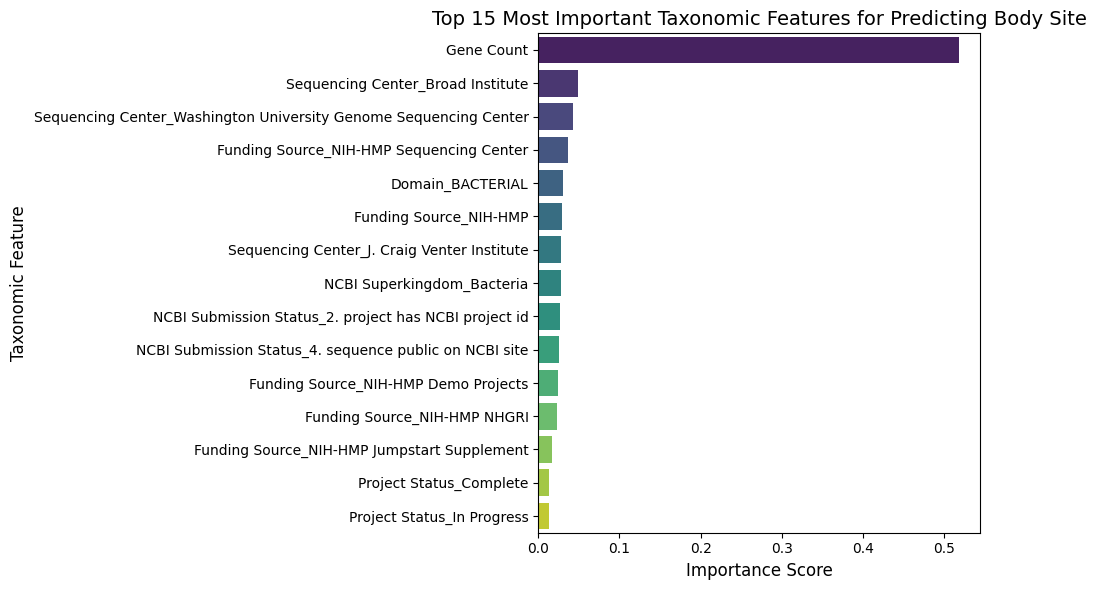

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("正在绘制特征重要性图谱...\n")

# 1. 从刚才训练好的随机森林模型中，提取所有特征的“重要性得分”
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. 把得分和特征名称拼成一个表格，方便排序
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 3. 按得分从高到低排序，我们只看排名前 15 的核心特征
top_features = importance_df.sort_values(by='Importance', ascending=False).head(15)

# 4. 开始画图
plt.figure(figsize=(10, 6))
# 使用 seaborn 画水平条形图
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')

# 添加图表标题和标签
plt.title('Top 15 Most Important Taxonomic Features for Predicting Body Site', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Taxonomic Feature', fontsize=12)

# 自动调整布局并显示图表
plt.tight_layout()
plt.show()

经过你的专家审查，剔除了干扰项。
真正喂给 AI 的纯生物学特征有：
 ['Domain', 'NCBI Superkingdom', 'HMP Isolation Body Site', 'Current Finishing Level']
----------------------------------------
🎯 剔除作弊特征后，AI 凭借真实分类学规律的预测准确率为: 33.10%



/tmp/ipykernel_2152/3908900072.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features_real, palette='magma')


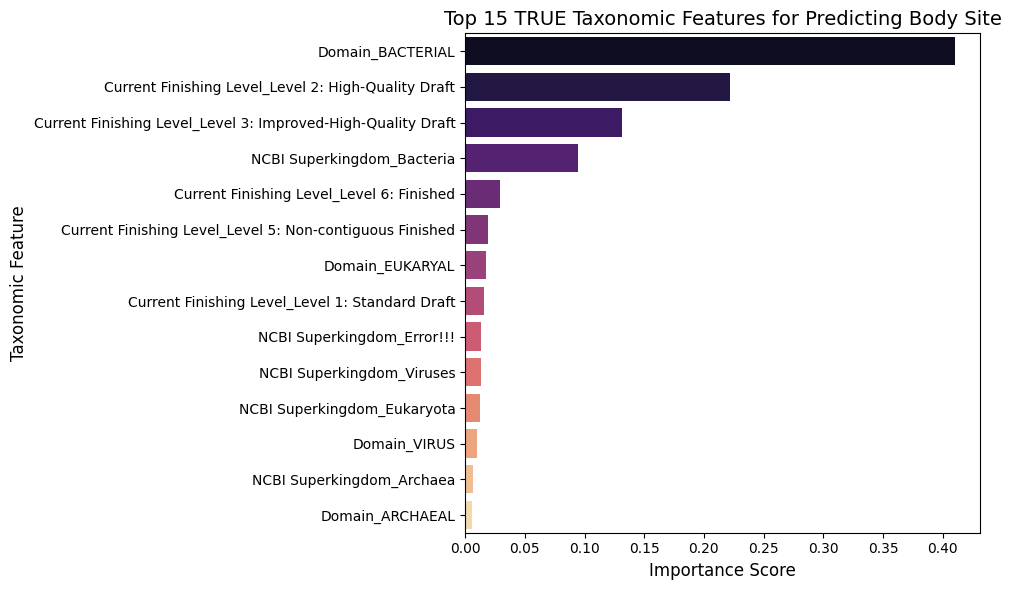

In [5]:
# 1. 更加严格的数据清洗：剔除所有非生物学特征的“干扰列”
bad_keywords = ['ID', 'Name', 'Center', 'Funding', 'Status', 'Gene Count']
useful_cols = [col for col in df.columns if not any(keyword in col for keyword in bad_keywords)]

print("经过你的专家审查，剔除了干扰项。")
print("真正喂给 AI 的纯生物学特征有：\n", useful_cols)
print("-" * 40)

# ================= 重新走一遍流程 =================
df_clean = df[useful_cols].copy()
df_clean = df_clean.dropna(subset=['HMP Isolation Body Site'])

y_text = df_clean['HMP Isolation Body Site']
X_text = df_clean.drop('HMP Isolation Body Site', axis=1)

# 编码
le = LabelEncoder()
y = le.fit_transform(y_text)
X = pd.get_dummies(X_text)

# 拆分与训练
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model_real = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_real.fit(X_train, y_train)

# 打印真实准确率
accuracy_real = accuracy_score(y_test, rf_model_real.predict(X_test))
print(f"🎯 剔除作弊特征后，AI 凭借真实分类学规律的预测准确率为: {accuracy_real * 100:.2f}%\n")

# ================= 重新画图 =================
importances_real = rf_model_real.feature_importances_
importance_df_real = pd.DataFrame({'Feature': X.columns, 'Importance': importances_real})
top_features_real = importance_df_real.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_features_real, palette='magma')
plt.title('Top 15 TRUE Taxonomic Features for Predicting Body Site', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Taxonomic Feature', fontsize=12)
plt.tight_layout()
plt.show()

【专家干预】正在从拉丁文学名中提取属 (Genus) 水平特征...

🎯 仅使用 Genus (属) 特征，AI 的预测准确率飙升至: 53.69%



/tmp/ipykernel_2152/3620486977.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features_final, palette='mako')
/tmp/ipykernel_2152/3620486977.py:49: UserWarning: Glyph 23646 (\N{CJK UNIFIED IDEOGRAPH-5C5E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23646 (\N{CJK UNIFIED IDEOGRAPH-5C5E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


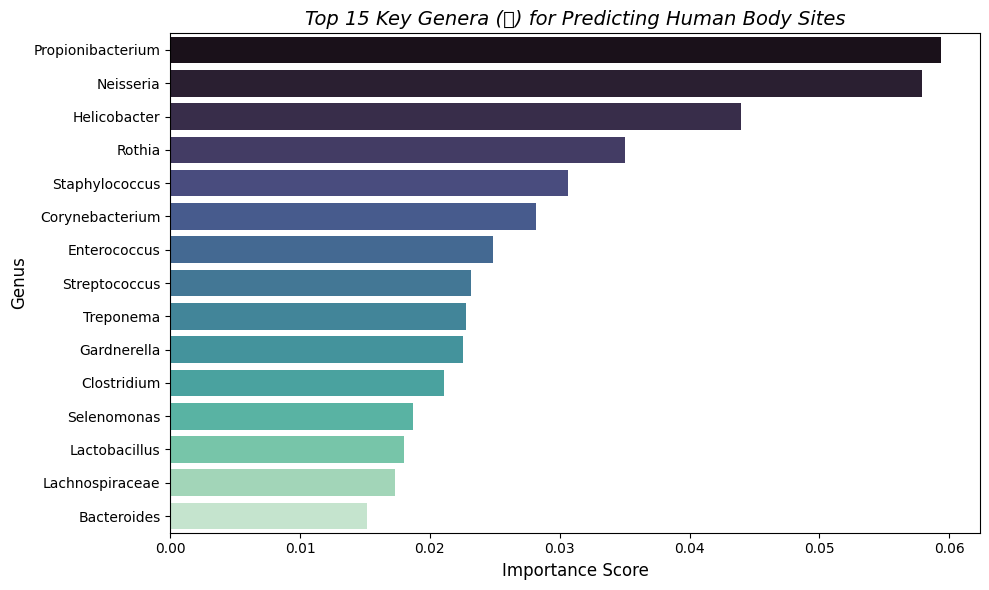

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

print("【专家干预】正在从拉丁文学名中提取属 (Genus) 水平特征...\n")

# 1. 剔除缺失值
df_clean = df.dropna(subset=['HMP Isolation Body Site', 'Organism Name']).copy()

# 2. 核心魔法：提取 Organism Name 的第一个单词作为属名 (Genus)
# 比如把 "Acinetobacter baumannii" 切分成 "Acinetobacter"
df_clean['Genus'] = df_clean['Organism Name'].apply(lambda x: str(x).split()[0])

# 3. 这一次，我们实行“白名单”制度，只用纯净的 Genus 作为特征！
X_text = df_clean[['Genus']]
y_text = df_clean['HMP Isolation Body Site']

# 4. 文字转数字
le = LabelEncoder()
y = le.fit_transform(y_text)
X = pd.get_dummies(X_text)

# 5. 训练模型
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_final.fit(X_train, y_train)

# 6. 准确率评估
accuracy_final = accuracy_score(y_test, rf_model_final.predict(X_test))
print(f"🎯 仅使用 Genus (属) 特征，AI 的预测准确率飙升至: {accuracy_final * 100:.2f}%\n")

# 7. 终极画图
importances_final = rf_model_final.feature_importances_
importance_df_final = pd.DataFrame({'Feature': X.columns, 'Importance': importances_final})
# 把特征名里的 'Genus_' 前缀去掉，让图表更美观
importance_df_final['Feature'] = importance_df_final['Feature'].str.replace('Genus_', '')

top_features_final = importance_df_final.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_features_final, palette='mako')
plt.title('Top 15 Key Genera (属) for Predicting Human Body Sites', fontsize=14, fontstyle='italic')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Genus', fontsize=12)
plt.tight_layout()
plt.show()